#1. Notebook Header & Imports

In [2]:
# EDA for Trade Settlement Failure Prediction
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline



C:\Users\vivek\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [3]:
os.chdir('D:\ShivaniG_AI_ML\capital-markets-trade-settlement-ml')

In [4]:
os.getcwd()

'D:\\ShivaniG_AI_ML\\capital-markets-trade-settlement-ml'

In [5]:
# Load feature-engineered dataset
df = pd.read_csv("data/trade_settlement_features.csv")

In [6]:
df.head(5)

,trade_id,security_isin,trade_amount,counterparty_risk_score,historical_fail_rate,market_volatility_index,settlement_delay_days,settlement_failed,security_type_Derivative,security_type_Equity,...,currency_USD,counterparty_Barclays,counterparty_Citi,counterparty_Goldman Sachs,counterparty_HSBC,counterparty_JPMorgan,counterparty_Morgan Stanley,trade_size_category_Medium,trade_size_category_Large,trade_size_category_XL
0,1,US634895718,3576311.75,0.920,0.140,37.12,3,1,False,False,...,False,False,False,False,True,False,False,False,False,True
1,2,US299900595,2843515.34,0.488,0.017,22.34,1,0,False,True,...,True,False,False,False,False,False,True,False,False,True
2,3,US962061404,4885423.38,0.064,0.149,33.80,1,0,False,False,...,False,False,True,False,False,False,False,False,False,True
3,4,US887846414,1371385.12,0.229,0.029,16.09,3,0,True,False,...,True,False,False,False,False,True,False,False,True,False
4,5,US227521863,800281.37,0.579,0.005,24.81,4,0,False,True,...,False,False,False,False,False,True,False,False,True,False


#2. Dataset Overview

(10000, 22)
Index(['trade_id', 'security_isin', 'trade_amount', 'counterparty_risk_score',
       'historical_fail_rate', 'market_volatility_index',
       'settlement_delay_days', 'settlement_failed',
       'security_type_Derivative', 'security_type_Equity', 'currency_GBP',
       'currency_JPY', 'currency_USD', 'counterparty_Barclays',
       'counterparty_Citi', 'counterparty_Goldman Sachs', 'counterparty_HSBC',
       'counterparty_JPMorgan', 'counterparty_Morgan Stanley',
       'trade_size_category_Medium', 'trade_size_category_Large',
       'trade_size_category_XL'],
      dtype='str')
trade_id                       0
security_isin                  0
trade_amount                   0
counterparty_risk_score        0
historical_fail_rate           0
market_volatility_index        0
settlement_delay_days          0
settlement_failed              0
security_type_Derivative       0
security_type_Equity           0
currency_GBP                   0
currency_JPY                   0
cu

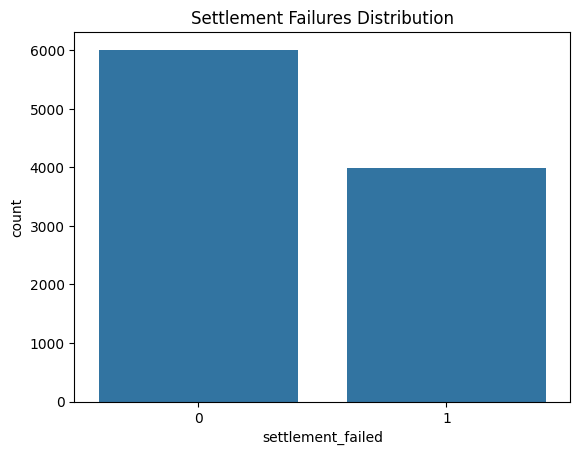

In [7]:
# Check shape and columns
print(df.shape)
print(df.columns)

# Check for missing values
print(df.isnull().sum())

# Overview of target variable
print(df['settlement_failed'].value_counts())
sns.countplot(x='settlement_failed', data=df)
plt.title("Settlement Failures Distribution")
plt.show()

# dataset is balanced / slightly imbalanced and that most trades settle successfully.

3. Numeric Feature Exploration

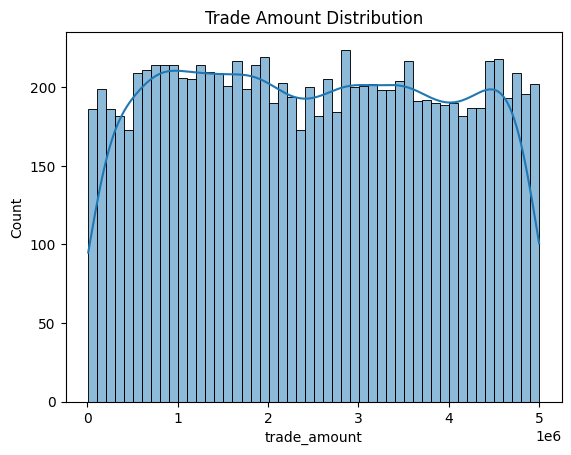

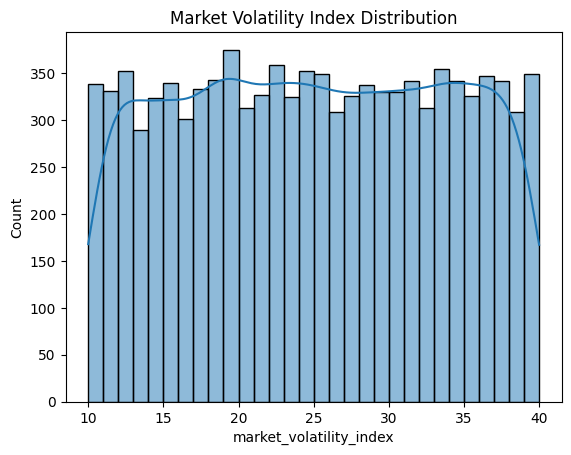

In [8]:
# Summary statistics
df.describe()

# Trade Amount distribution
sns.histplot(df['trade_amount'], bins=50, kde=True)
plt.title("Trade Amount Distribution")
plt.show()

# Market Volatility Index distribution
sns.histplot(df['market_volatility_index'], bins=30, kde=True)
plt.title("Market Volatility Index Distribution")
plt.show()

#4. Settlement Failures vs Key Features

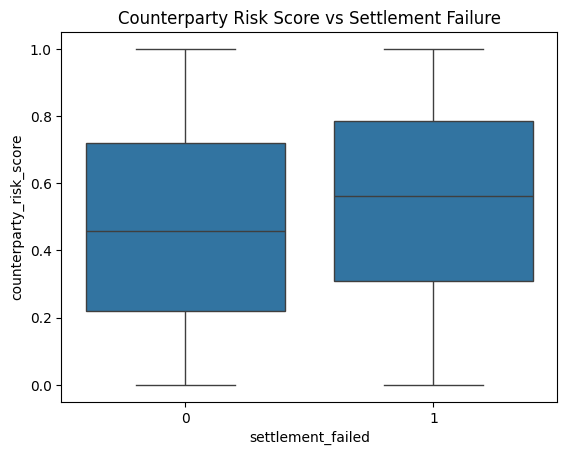

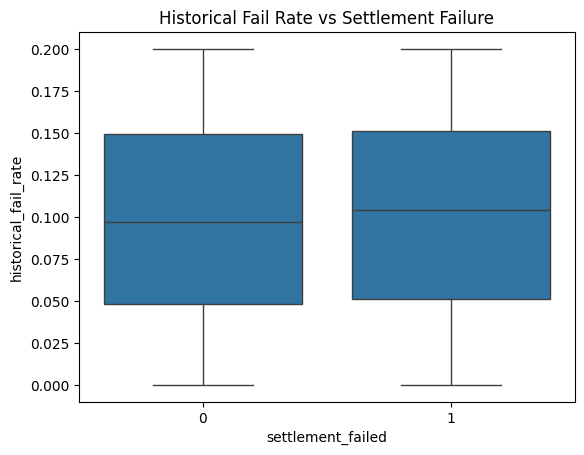

In [13]:
# Counterparty risk score vs failure
sns.boxplot(x='settlement_failed', y='counterparty_risk_score', data=df)
plt.title("Counterparty Risk Score vs Settlement Failure")
plt.savefig(r'notebooks\images\counterparty_failures.png')
plt.show()


# Historical fail rate vs failure
sns.boxplot(x='settlement_failed', y='historical_fail_rate', data=df)
plt.title("Historical Fail Rate vs Settlement Failure")
plt.show()

#5. Correlation Heatmap

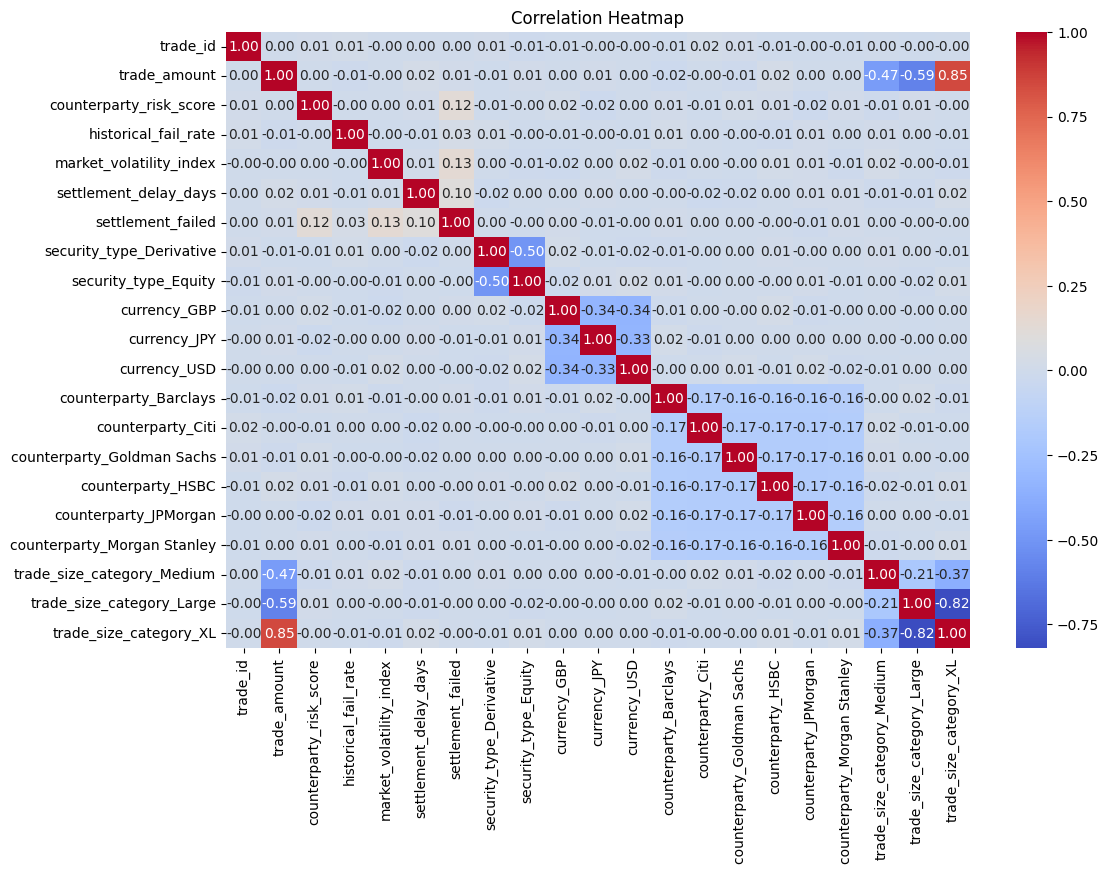

In [11]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

#6. Feature Importance from Trained Model

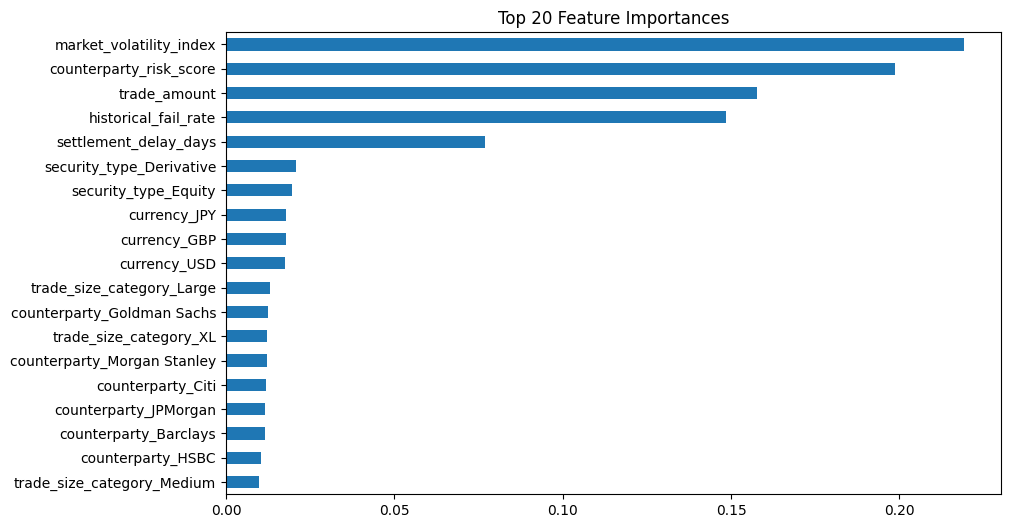

In [14]:
import joblib

# Load trained model
model = joblib.load("models/settlement_prediction_model.pkl")

# Get feature importances
importances = pd.Series(model.feature_importances_, index=df.drop(['trade_id','security_isin','settlement_failed'], axis=1).columns)
importances = importances.sort_values(ascending=False)

# Plot top 20 features
plt.figure(figsize=(10,6))
importances.head(20).plot(kind='barh')
plt.title("Top 20 Feature Importances")
plt.gca().invert_yaxis()
plt.savefig(r'notebooks\images\feature_importance.png')
plt.show()


#Summary: Settlement failures are highly influenced by counterparty risk, historical failure rate,
and market volatility. The ML model can flag high-risk trades, reducing operational risk and settlement penalties.